In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("charts", exist_ok=True)

# Strict Rule: Read ONLY train set for EDA
train_df = pd.read_csv(os.path.join("artifacts", "train.csv"))
print(f"Loaded Train Dataset Shape: {train_df.shape}")

Loaded Train Dataset Shape: (67534, 20)


In [2]:
print("--- Data Types & Non-Null Counts ---")
print(train_df.info())

print("\n--- Missing Values Summary ---")
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

--- Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67534 entries, 0 to 67533
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       67534 non-null  object 
 1   customer_id                    67534 non-null  object 
 2   order_status                   67534 non-null  object 
 3   order_purchase_timestamp       67534 non-null  object 
 4   order_approved_at              67520 non-null  object 
 5   order_delivered_carrier_date   67532 non-null  object 
 6   order_delivered_customer_date  67532 non-null  object 
 7   order_estimated_delivery_date  67534 non-null  object 
 8   customer_unique_id             67534 non-null  object 
 9   customer_zip_code_prefix       67534 non-null  int64  
 10  customer_city                  67534 non-null  object 
 11  customer_state                 67534 non-null  object 
 12  total_pri

--- Numerical Summary ---
                                  mean           std      min       50%  \
customer_zip_code_prefix  36010.954467  29908.338139  1004.00  25959.50   
total_price                 135.887637    205.187080     2.29     85.00   
total_freight                22.245584     20.001901     0.00     16.79   
num_items                     1.142062      0.541621     1.00      1.00   
num_unique_sellers            1.012053      0.114811     1.00      1.00   
total_payment               158.172122    214.278487    10.07    104.19   
max_installments              2.974590      2.755158     1.00      2.00   
is_late                       0.090266      0.286564     0.00      0.00   

                               max  
customer_zip_code_prefix  99980.00  
total_price               13440.00  
total_freight              1002.29  
num_items                    21.00  
num_unique_sellers            5.00  
total_payment             13664.08  
max_installments             24.00  
is

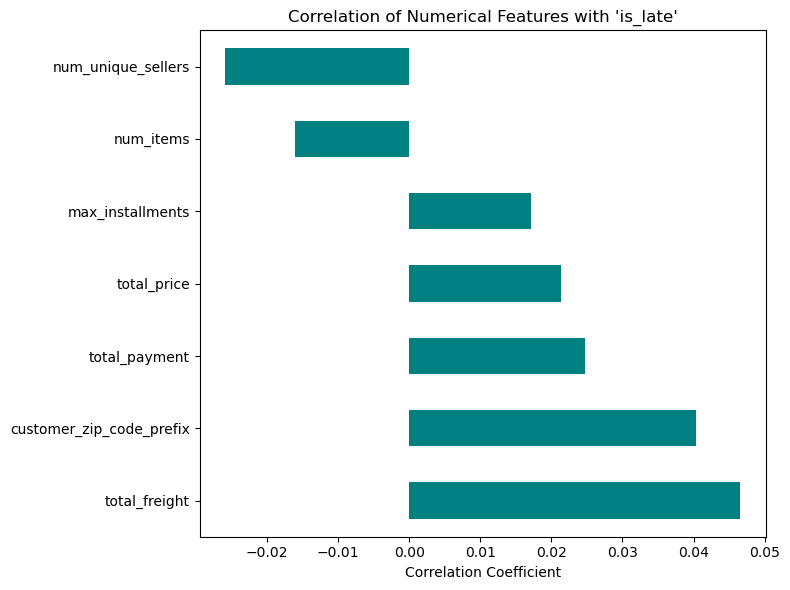

In [3]:
# Statistical summary for numerical columns
num_cols = train_df.select_dtypes(include=[np.number]).columns
print("--- Numerical Summary ---")
print(train_df[num_cols].describe().T[['mean', 'std', 'min', '50%', 'max']])

# Correlation with target
plt.figure(figsize=(8, 6))
corr = train_df[num_cols].corr()['is_late'].sort_values(ascending=False)
corr.drop('is_late').plot(kind='barh', color='teal')
plt.title("Correlation of Numerical Features with 'is_late'")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.savefig(os.path.join("charts", "numerical_correlation.png"))
plt.show()

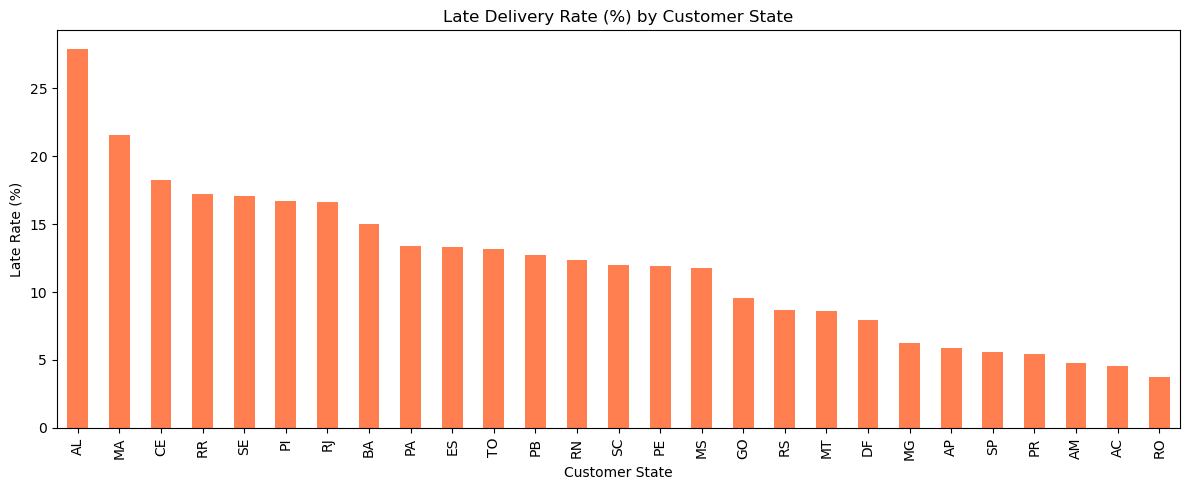

In [4]:
# Late delivery rate by Customer State
plt.figure(figsize=(12, 5))
state_late = train_df.groupby('customer_state')['is_late'].mean().sort_values(ascending=False) * 100
state_late.plot(kind='bar', color='coral')
plt.title("Late Delivery Rate (%) by Customer State")
plt.ylabel("Late Rate (%)")
plt.xlabel("Customer State")
plt.tight_layout()
plt.savefig(os.path.join("charts", "late_rate_by_state.png"))
plt.show()

In [5]:
summary_text = f"""--- EDA Findings Summary ---
1. Train Records Analyzed: {len(train_df)}
2. Target Imbalance: {train_df['is_late'].mean()*100:.2f}% late orders in train set.
3. Missing Values: Found in timestamps, freight, and payment columns (handled in Feature Engineering).
4. Key Insights: Certain states exhibit significantly higher delivery delay rates.
"""

with open(os.path.join("artifacts", "eda_summary.txt"), "w") as f:
    f.write(summary_text)

print("Saved EDA summary and charts successfully!")

Saved EDA summary and charts successfully!
